<a href="https://colab.research.google.com/github/it25102877/IT2011-AIML-Project/blob/main/Linear_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/final_preprocessed_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Mounted at /content/drive
Dataset shape: (46173, 79)

Columns: ['movie_name', 'Ratings', 'Ratings_scaled', 'emotion', 'emotion_label', 'cleaned_review', 'lemmatized_review', 'word_count_scaled', 'char_count_scaled', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western', 'LSA_1', 'LSA_2', 'LSA_3', 'LSA_4', 'LSA_5', 'LSA_6', 'LSA_7', 'LSA_8', 'LSA_9', 'LSA_10', 'LSA_11', 'LSA_12', 'LSA_13', 'LSA_14', 'LSA_15', 'LSA_16', 'LSA_17', 'LSA_18', 'LSA_19', 'LSA_20', 'LSA_21', 'LSA_22', 'LSA_23', 'LSA_24', 'LSA_25', 'LSA_26', 'LSA_27', 'LSA_28', 'LSA_29', 'LSA_30', 'LSA_31', 'LSA_32', 'LSA_33', 'LSA_34', 'LSA_35', 'LSA_36', 'LSA_37', 'LSA_38', 'LSA_39', 'LSA_40', 'LSA_41', 'LSA_42', 'LSA_43', 'LSA_44', 'LSA_45',

,movie_name,Ratings,Ratings_scaled,emotion,emotion_label,cleaned_review,lemmatized_review,word_count_scaled,char_count_scaled,genre_Action,...,LSA_41,LSA_42,LSA_43,LSA_44,LSA_45,LSA_46,LSA_47,LSA_48,LSA_49,LSA_50
0,Waiting to Exhale,3.0,0.222222,anticipation,1,it had some laughs but overall the motivation ...,laugh overall motivation character incomprehen...,-0.762821,-0.720442,0,...,0.036990,-0.054270,0.020441,0.048175,0.018404,-0.007786,0.003789,-0.011600,-0.021951,0.036462
1,Waiting to Exhale,4.0,0.333333,anticipation,1,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,1.173077,1.308287,0,...,0.025372,0.001595,-0.012987,0.029608,-0.006854,0.009810,-0.021013,0.007206,0.010680,0.004767
2,Waiting to Exhale,4.0,0.333333,anticipation,1,angela basset was good as expected but whitney...,angela basset good expected whitney range scre...,-0.839744,-0.773481,0,...,0.027154,-0.034242,0.050720,0.126149,0.041413,0.007349,-0.076408,0.077268,-0.022318,0.013545


In [3]:
feature_cols = (
    ['Ratings_scaled', 'word_count_scaled', 'char_count_scaled'] +
    [c for c in df.columns if c.startswith('genre_')] +
    [c for c in df.columns if c.startswith('LSA_')]
)

X = df[feature_cols]
y = df['emotion_label']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())

Feature matrix shape: (46173, 73)
Target shape: (46173,)

Class distribution:
emotion_label
0     3638
1     7336
2     1670
3     3460
4     7861
5     4812
6    17339
7       57
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 36938
Testing samples : 9235


In [5]:
baseline_svm = LinearSVC(max_iter=2000, random_state=42)
baseline_svm.fit(X_train, y_train)
y_pred_baseline = baseline_svm.predict(X_test)

print("=== Baseline Linear SVM Results ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Precision:", round(precision_score(y_test, y_pred_baseline, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_baseline, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_baseline, average='weighted'), 4))

=== Baseline Linear SVM Results ===
Accuracy : 0.3858
Precision: 0.3225
Recall   : 0.3858
F1-Score : 0.2645


In [6]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [2000]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 2000}
Best CV F1-Score: 0.299


In [7]:
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

print("=== Tuned Linear SVM Results ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_best, average='weighted'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

=== Tuned Linear SVM Results ===
Accuracy : 0.2847
Precision: 0.3202
Recall   : 0.2847
F1-Score : 0.2908

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.28      0.25       728
           1       0.22      0.07      0.11      1467
           2       0.12      0.31      0.17       334
           3       0.21      0.33      0.25       692
           4       0.34      0.22      0.27      1572
           5       0.20      0.16      0.17       963
           6       0.45      0.43      0.44      3468
           7       0.01      0.91      0.02        11

    accuracy                           0.28      9235
   macro avg       0.22      0.34      0.21      9235
weighted avg       0.32      0.28      0.29      9235



In [8]:
y_train_pred = best_svm.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test, y_pred_best)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1  = f1_score(y_test, y_pred_best, average='weighted')

print("="*55)
print("OVERFITTING / UNDERFITTING DIAGNOSIS")
print("="*55)
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy     : {test_accuracy:.4f}")
print(f"Difference        : {train_accuracy - test_accuracy:.4f}")
print()
print(f"Training F1-Score : {train_f1:.4f}")
print(f"Test F1-Score     : {test_f1:.4f}")
print(f"Difference        : {train_f1 - test_f1:.4f}")
print("="*55)

gap = train_accuracy - test_accuracy

if gap > 0.10:
    print("→ Diagnosis: OVERFITTING")
elif train_accuracy < 0.60 and test_accuracy < 0.60:
    print("→ Diagnosis: UNDERFITTING")
else:
    print("→ Diagnosis: GOOD FIT")

OVERFITTING / UNDERFITTING DIAGNOSIS
Training Accuracy : 0.2963
Test Accuracy     : 0.2847
Difference        : 0.0116

Training F1-Score : 0.3042
Test F1-Score     : 0.2908
Difference        : 0.0134
→ Diagnosis: UNDERFITTING


In [9]:
improved_svm = LinearSVC(
    C=10,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

improved_svm.fit(X_train, y_train)
y_pred_improved = improved_svm.predict(X_test)

print("=== Improved Linear SVM (Underfitting Fix) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_improved), 4))
print("Precision:", round(precision_score(y_test, y_pred_improved, average='weighted'), 4))
print("Recall   :", round(recall_score(y_test, y_pred_improved, average='weighted'), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_improved, average='weighted'), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

=== Improved Linear SVM (Underfitting Fix) ===
Accuracy : 0.2886
Precision: 0.3185
Recall   : 0.2886
F1-Score : 0.2926

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.29      0.25       728
           1       0.21      0.07      0.11      1467
           2       0.11      0.33      0.17       334
           3       0.21      0.33      0.25       692
           4       0.33      0.23      0.27      1572
           5       0.19      0.16      0.17       963
           6       0.46      0.43      0.44      3468
           7       0.02      0.91      0.03        11

    accuracy                           0.29      9235
   macro avg       0.22      0.34      0.21      9235
weighted avg       0.32      0.29      0.29      9235



In [10]:
y_train_pred_imp = improved_svm.predict(X_train)

train_acc_imp = accuracy_score(y_train, y_train_pred_imp)
test_acc_imp  = accuracy_score(y_test, y_pred_improved)

print("=== New Diagnosis after Improvement ===")
print(f"Training Accuracy : {train_acc_imp:.4f}")
print(f"Test Accuracy     : {test_acc_imp:.4f}")
print(f"Difference        : {train_acc_imp - test_acc_imp:.4f}")

gap = train_acc_imp - test_acc_imp

if gap > 0.10:
    print("→ Diagnosis: OVERFITTING")
elif train_acc_imp < 0.60 and test_acc_imp < 0.60:
    print("→ Diagnosis: STILL UNDERFITTING")
else:
    print("→ Diagnosis: GOOD FIT (Improved)")

=== New Diagnosis after Improvement ===
Training Accuracy : 0.2993
Test Accuracy     : 0.2886
Difference        : 0.0107
→ Diagnosis: STILL UNDERFITTING


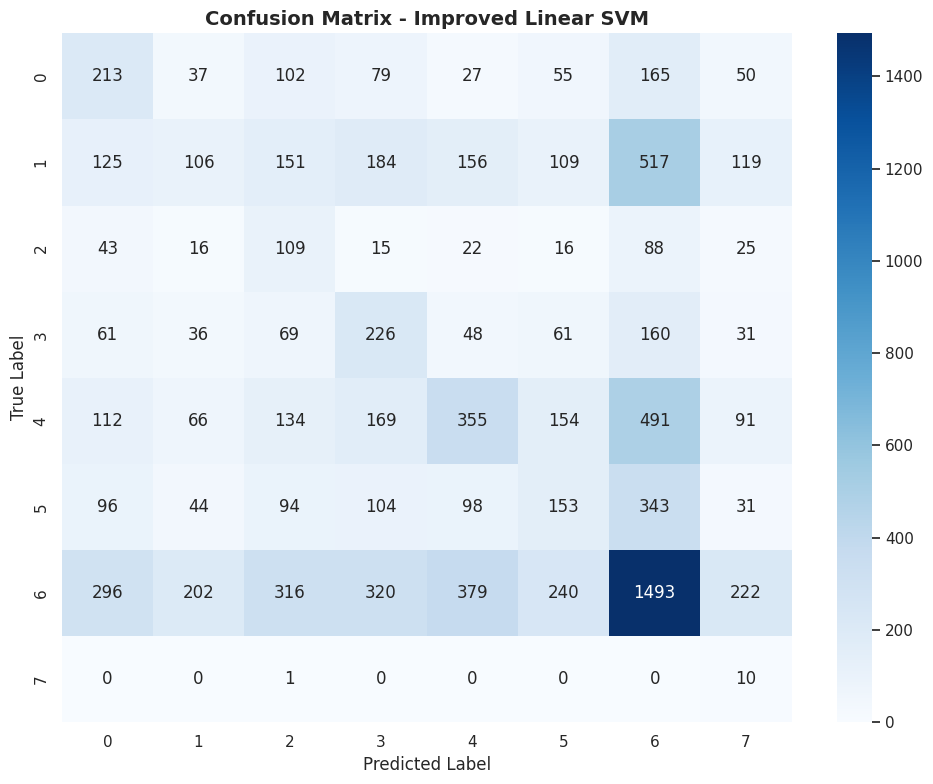

In [11]:
cm = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Improved Linear SVM", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('linear_svm_confusion_matrix.png', dpi=300)
plt.show()

In [12]:
comparison = pd.DataFrame({
    "Model Variety": [
        "Baseline Linear SVM",
        "Tuned Linear SVM (GridSearchCV)",
        "Improved Linear SVM (Underfitting Fix)"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_baseline), 4),
        round(accuracy_score(y_test, y_pred_best), 4),
        round(accuracy_score(y_test, y_pred_improved), 4)
    ],
    "F1-Score (Weighted)": [
        round(f1_score(y_test, y_pred_baseline, average='weighted'), 4),
        round(f1_score(y_test, y_pred_best, average='weighted'), 4),
        round(f1_score(y_test, y_pred_improved, average='weighted'), 4)
    ]
})

print(comparison)

                            Model Variety  Accuracy  F1-Score (Weighted)
0                     Baseline Linear SVM    0.3858               0.2645
1         Tuned Linear SVM (GridSearchCV)    0.2847               0.2908
2  Improved Linear SVM (Underfitting Fix)    0.2886               0.2926


In [13]:
print("""
============================================================
LINEAR SVM - SUMMARY
Student: Fernando B. K. H. (IT25102631)
============================================================

1. Model Suitability:
   - Multi-class emotion classification (8 classes)
   - Linear SVM is suitable for high-dimensional numerical features

2. Implementation:
   - Library: scikit-learn (LinearSVC)

3. Hyperparameter Tuning:
   - GridSearchCV + StratifiedKFold
   - Tuned parameters: C, class_weight

4. Underfitting Fix:
   - Increased C to 10
   - Added class_weight='balanced'
   - Increased max_iter to 5000

5. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)

6. Validation Method:
   - Stratified Train-Test Split (80/20)

7. Overfitting/Underfitting Check:
   - Compared Training vs Test performance

8. Limitations:
   - Assumes linear separability
   - Affected by class imbalance

9. Improvements:
   - Fixed underfitting by increasing model flexibility
============================================================
""")


LINEAR SVM - SUMMARY
Student: Fernando B. K. H. (IT25102631)

1. Model Suitability:
   - Multi-class emotion classification (8 classes)
   - Linear SVM is suitable for high-dimensional numerical features

2. Implementation:
   - Library: scikit-learn (LinearSVC)

3. Hyperparameter Tuning:
   - GridSearchCV + StratifiedKFold
   - Tuned parameters: C, class_weight

4. Underfitting Fix:
   - Increased C to 10
   - Added class_weight='balanced'
   - Increased max_iter to 5000

5. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)

6. Validation Method:
   - Stratified Train-Test Split (80/20)

7. Overfitting/Underfitting Check:
   - Compared Training vs Test performance

8. Limitations:
   - Assumes linear separability
   - Affected by class imbalance

9. Improvements:
   - Fixed underfitting by increasing model flexibility

